# EDA: Energy Theft Detection Dataset

Mục tiêu: hiểu cấu trúc dữ liệu, phân phối nhãn, missing/zero/outlier và các tín hiệu khác biệt giữa Normal và Theft.

Lưu ý: các phân tích trong notebook này dùng raw data, trước khi preprocessing.

## 1. Setup & Data Loading

Question: Notebook đang đọc dữ liệu nào, ở đâu, và đây có phải raw data không?

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style biểu đồ cho toàn bộ notebook
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Đọc dữ liệu thô để EDA; bước này chỉ phân tích, không ghi đè dữ liệu
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "data_set.csv"
if not DATA_PATH.exists():
    DATA_PATH = PROJECT_ROOT / "data" / "raw" / "data set.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Shape: {df.shape[0]:,} customers x {df.shape[1]:,} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("Note: This is raw data before preprocessing.")

Dataset loaded from: c:\Users\asus\Documents\HocTap\HK4\CS114 - Machine Learning\CS114 -  ML Project - Energy Theft Detection\data\raw\data set.csv
Shape: 42,372 customers x 1,036 columns
Memory usage: 337.86 MB
Note: This is raw data before preprocessing.


## 2. Data Overview

Question: Dataset gồm những cột nào, thời gian theo dõi bao lâu, và raw data có vấn đề chất lượng dữ liệu nào cần chú ý?

In [20]:
# Tách các cột tiêu thụ điện theo ngày; loại CONS_NO và FLAG vì không phải chuỗi tiêu thụ
cons_cols = [c for c in df.columns if c not in ['CONS_NO', 'FLAG']]

overview = pd.DataFrame({
    'Item': [
        'Total customers', 'Tracking days', 'Total consumption cells',
        'ID column', 'Target column', 'Date range'
    ],
    'Value': [
        f'{len(df):,}',
        f'{len(cons_cols):,}',
        f'{len(df) * len(cons_cols):,}',
        'CONS_NO',
        'FLAG (0=Normal, 1=Theft)',
        f'{cons_cols[0]} → {cons_cols[-1]}',
    ]
})
display(overview)

quality_checks = pd.DataFrame({
    'Check': [
        'Duplicate CONS_NO',
        'Duplicate consumption series',
        'Negative consumption cells',
        'Raw outlier cells (>500 kWh/day)',
        'Zero consumption cells',
    ],
    'Count': [
        df['CONS_NO'].duplicated().sum(),
        df.duplicated(subset=cons_cols).sum(),
        (df[cons_cols] < 0).sum().sum(),
        (df[cons_cols] > 500).sum().sum(),
        (df[cons_cols] == 0).sum().sum(),
    ]
})
display(quality_checks)

sample_cols = ['CONS_NO', 'FLAG'] + cons_cols[:3] + cons_cols[-3:]
display(df[sample_cols].head())

print('Observation: Raw data có nhiều cột ngày; các kiểm tra duplicate/negative/outlier/zero giúp định hướng preprocessing_v2.')

,Item,Value
0,Total customers,"42,372"
1,Tracking days,"1,034"
2,Total consumption cells,"43,812,648"
3,ID column,CONS_NO
4,Target column,"FLAG (0=Normal, 1=Theft)"
5,Date range,1/1/2014 → 10/31/2016


,Check,Count
0,Duplicate CONS_NO,0
1,Duplicate consumption series,878
2,Negative consumption cells,0
3,Raw outlier cells (>500 kWh/day),21070
4,Zero consumption cells,5788603


,CONS_NO,FLAG,1/1/2014,1/2/2014,1/3/2014,10/29/2016,10/30/2016,10/31/2016
0,0387DD8A07E07FDA6271170F86AD9151,1,0.0,0.0,0.01,0.38,0.70,0.25
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,0.0,0.0,0.00,17.38,13.94,14.14
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,0.0,0.0,0.00,2.89,1.88,1.16
3,B32AC8CC6D5D805AC053557AB05F5343,1,0.0,0.0,0.00,16.10,17.51,16.67
4,EDFC78B07BA2908B3395C4EB2304665E,1,0.0,0.0,0.00,2.10,1.16,2.13


Observation: Raw data có nhiều cột ngày; các kiểm tra duplicate/negative/outlier/zero giúp định hướng preprocessing_v2.


## 3. Target Distribution Analysis

Question: Dataset có bị mất cân bằng giữa Normal và Theft không?

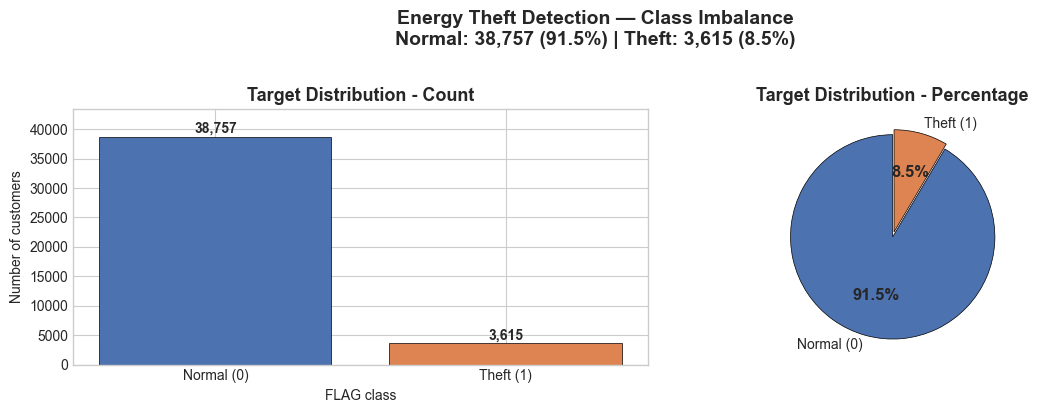


Normal customers (0): 38,757 (91.47%)
Theft customers (1):  3,615 (8.53%)
Imbalance ratio: 10.72:1

Observation: Dataset is highly imbalanced, so Accuracy alone is not enough. Later evaluation should prioritize Recall, F1-score, and PR-AUC.


In [21]:
# Kiểm tra phân phối nhãn để đánh giá mức mất cân bằng lớp
target_counts = df['FLAG'].value_counts().sort_index()
target_pct = df['FLAG'].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Biểu đồ cột: số lượng khách hàng theo từng nhãn
colors = ['#4C72B0', '#DD8452']
labels = ['Normal (0)', 'Theft (1)']
bars = axes[0].bar(labels, target_counts.values, color=colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Target Distribution - Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('FLAG class')
axes[0].set_ylabel('Number of customers')
axes[0].set_ylim(0, target_counts.max() * 1.12)

# Biểu đồ tròn: tỷ lệ phần trăm theo từng nhãn
wedges, texts, autotexts = axes[1].pie(
    target_pct.values, labels=labels, autopct='%1.1f%%',
    colors=colors, explode=(0, 0.05), startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5})
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
axes[1].set_title('Target Distribution - Percentage', fontsize=13, fontweight='bold')

plt.suptitle(f'Energy Theft Detection — Class Imbalance\n'
             f'Normal: {target_counts[0]:,} ({target_pct[0]:.1f}%) | '
             f'Theft: {target_counts[1]:,} ({target_pct[1]:.1f}%)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nNormal customers (0): {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"Theft customers (1):  {target_counts[1]:,} ({target_pct[1]:.2f}%)")
print(f"Imbalance ratio: {target_counts[0]/target_counts[1]:.2f}:1")
print('\nObservation: Dataset is highly imbalanced, so Accuracy alone is not enough. Later evaluation should prioritize Recall, F1-score, and PR-AUC.')

## 4. Consumption Statistics

Question: Daily consumption phân phối như thế nào, có bị lệch hoặc có outlier lớn không?

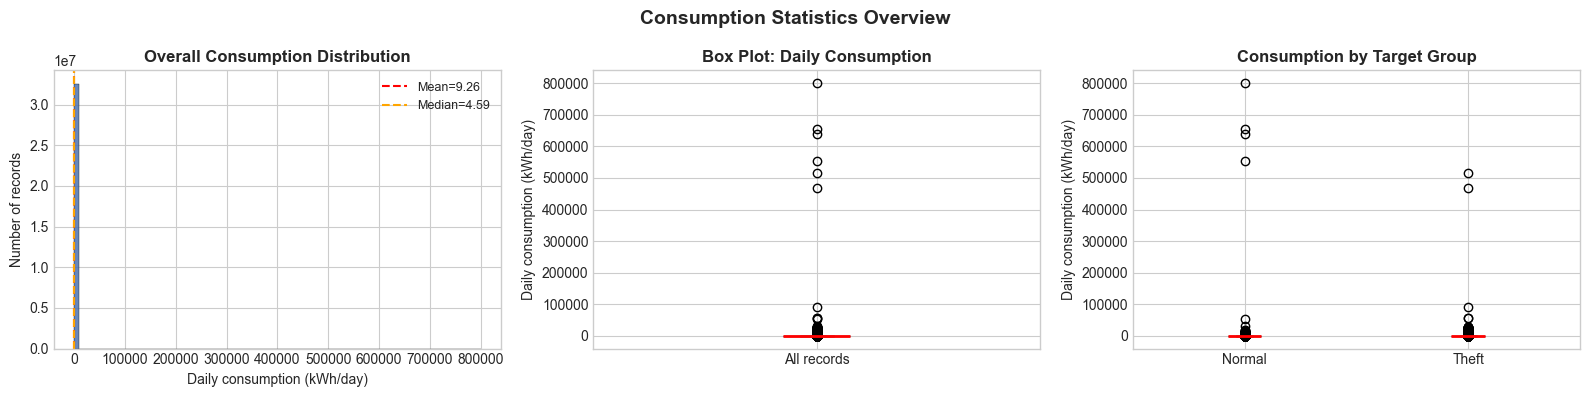

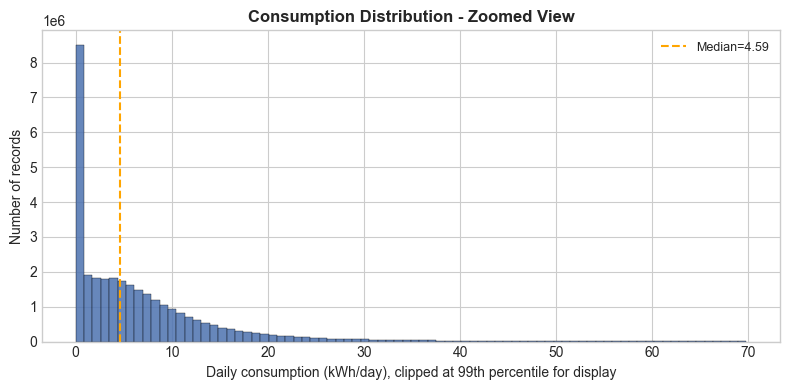


--- Overall Consumption Statistics ---
  Count:   32,579,120
  Mean:    9.259
  Std:     273.224
  Min:     0.000
  25%:     0.730
  Median:  4.590
  75%:     9.740
  Max:     800003.320

  Zero values: 5,788,603 (17.77%)

--- By Target Group ---
  Normal: mean=7.700, median=4.430, std=245.395, zeros=18.25%
  Theft: mean=27.531, median=7.010, std=493.372, zeros=12.13%

Observation: Consumption is highly skewed with large outliers. Mean can be distorted, so median/IQR/log and outlier-aware features are important.


In [22]:
# Gom toàn bộ ô tiêu thụ không bị thiếu; mỗi ô ngày-khách hàng được xem là một điểm dữ liệu
all_consumption = df[cons_cols].values.flatten()
all_consumption = all_consumption[~np.isnan(all_consumption)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Phân phối tổng thể của lượng điện tiêu thụ
axes[0].hist(all_consumption, bins=80, color='#4C72B0', edgecolor='black', linewidth=0.3, alpha=0.85)
axes[0].axvline(np.mean(all_consumption), color='red', linestyle='--', linewidth=1.5, label=f'Mean={np.mean(all_consumption):.2f}')
axes[0].axvline(np.median(all_consumption), color='orange', linestyle='--', linewidth=1.5, label=f'Median={np.median(all_consumption):.2f}')
axes[0].set_xlabel('Daily consumption (kWh/day)')
axes[0].set_ylabel('Number of records')
axes[0].set_title('Overall Consumption Distribution', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# 2. Box plot toàn bộ để nhìn độ lệch và outlier
bp = axes[1].boxplot(all_consumption, vert=True, patch_artist=True,
                     boxprops={'facecolor': '#4C72B0', 'alpha': 0.7},
                     medianprops={'color': 'red', 'linewidth': 2})
axes[1].set_ylabel('Daily consumption (kWh/day)')
axes[1].set_title('Box Plot: Daily Consumption', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['All records'])

# 3. So sánh phân phối tiêu thụ giữa nhóm normal và theft
normal_cons = df[df['FLAG'] == 0][cons_cols].values.flatten()
theft_cons = df[df['FLAG'] == 1][cons_cols].values.flatten()
normal_cons = normal_cons[~np.isnan(normal_cons)]
theft_cons = theft_cons[~np.isnan(theft_cons)]

bp2 = axes[2].boxplot([normal_cons, theft_cons], patch_artist=True,
                       labels=['Normal', 'Theft'],
                       boxprops={'facecolor': '#4C72B0', 'alpha': 0.7},
                       medianprops={'color': 'red', 'linewidth': 2})
axes[2].set_ylabel('Daily consumption (kWh/day)')
axes[2].set_title('Consumption by Target Group', fontsize=12, fontweight='bold')

plt.suptitle('Consumption Statistics Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_consumption_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

# Zoom vùng 99% đầu để tránh vài outlier cực lớn làm biểu đồ khó đọc
p99 = np.percentile(all_consumption, 99)
zoom_consumption = all_consumption[(all_consumption >= 0) & (all_consumption <= p99)]
plt.figure(figsize=(8, 4))
plt.hist(zoom_consumption, bins=80, color='#4C72B0', edgecolor='black', linewidth=0.3, alpha=0.85)
plt.axvline(np.median(all_consumption), color='orange', linestyle='--', linewidth=1.5, label=f'Median={np.median(all_consumption):.2f}')
plt.xlabel('Daily consumption (kWh/day), clipped at 99th percentile for display')
plt.ylabel('Number of records')
plt.title('Consumption Distribution - Zoomed View', fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02b_consumption_distribution_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

# In các thống kê mô tả chính của dữ liệu tiêu thụ
print("\n--- Overall Consumption Statistics ---")
print(f"  Count:   {len(all_consumption):,}")
print(f"  Mean:    {np.mean(all_consumption):.3f}")
print(f"  Std:     {np.std(all_consumption):.3f}")
print(f"  Min:     {np.min(all_consumption):.3f}")
print(f"  25%:     {np.percentile(all_consumption, 25):.3f}")
print(f"  Median:  {np.median(all_consumption):.3f}")
print(f"  75%:     {np.percentile(all_consumption, 75):.3f}")
print(f"  Max:     {np.max(all_consumption):.3f}")
print(f"\n  Zero values: {(all_consumption == 0).sum():,} ({(all_consumption == 0).mean()*100:.2f}%)")

print("\n--- By Target Group ---")
for label, data in [('Normal', normal_cons), ('Theft', theft_cons)]:
    print(f"  {label}: mean={np.mean(data):.3f}, median={np.median(data):.3f}, "
          f"std={np.std(data):.3f}, zeros={(data==0).mean()*100:.2f}%")

print('\nObservation: Consumption is highly skewed with large outliers. Mean can be distorted, so median/IQR/log and outlier-aware features are important.')

## 5. Missing Values Analysis

Question: Missing values có nhiều không, xuất hiện theo khách hàng/thời gian như thế nào, và có liên quan tới FLAG không?

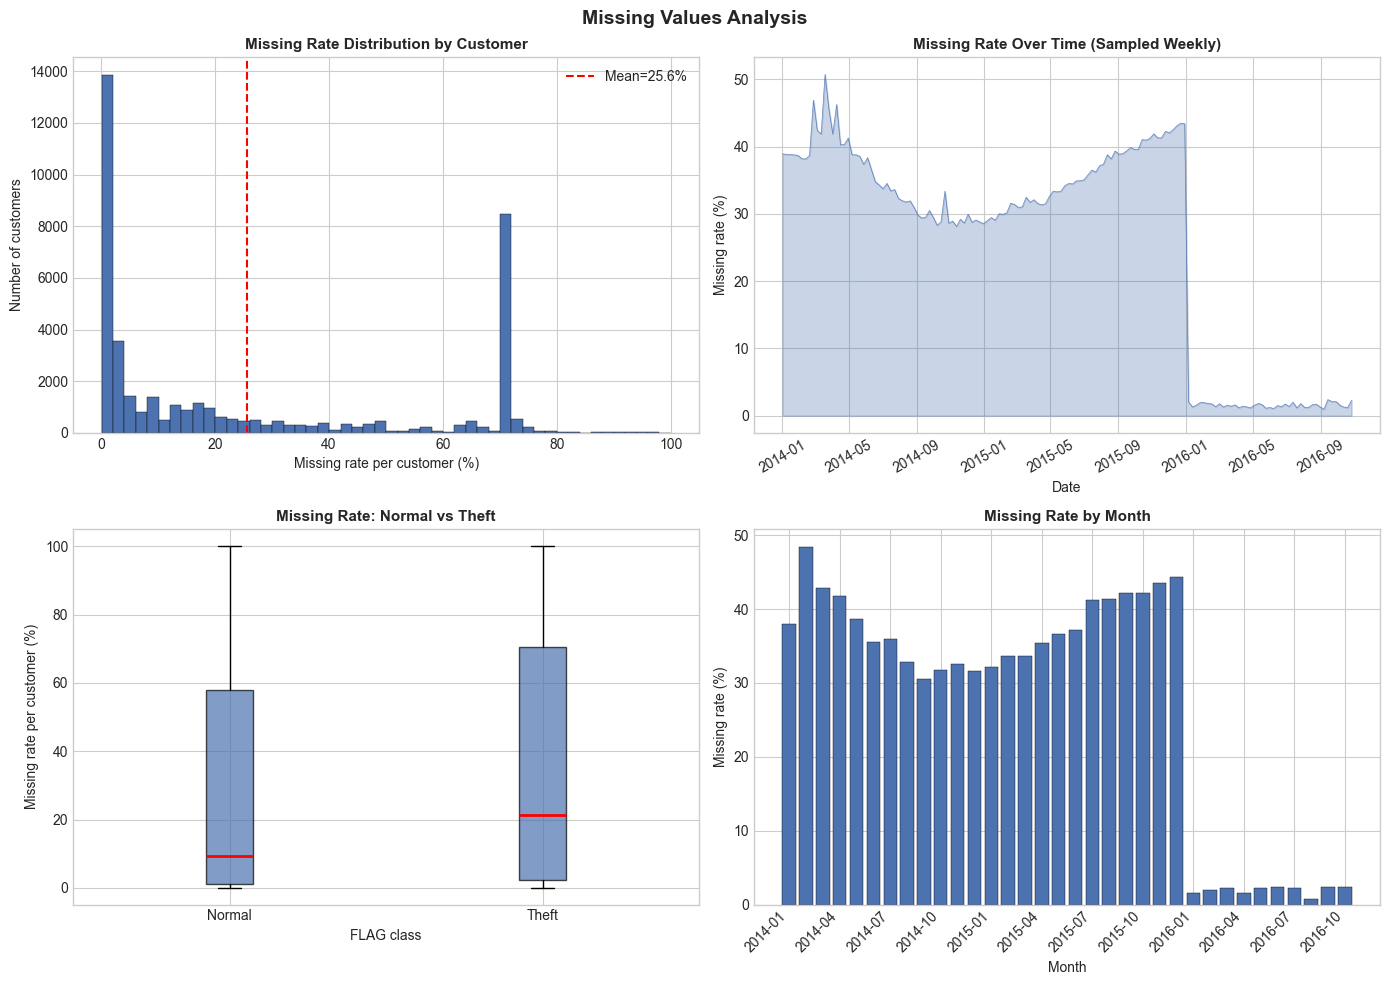


--- Missing Values Summary ---
  Total cells: 43,812,648
  Missing cells: 11,233,528
  Missing percentage: 25.64%
  Avg missing per customer: 25.64%
  Avg missing per day: 25.64%

  Normal customers avg missing: 25.10%
  Theft customers avg missing:  31.47%
  t-test p-value: 4.35e-37 (significant)
  Note: p-value < 0.05 means missing rate differs significantly between Normal and Theft.

Observation: Missing values are common and differ by FLAG, so missing-related features should be preserved instead of only being treated as noise.


In [23]:
# Phân tích giá trị thiếu trong các cột tiêu thụ điện
total_cells = df[cons_cols].size
missing_cells = df[cons_cols].isna().sum().sum()
missing_pct = missing_cells / total_cells * 100

# Tỷ lệ thiếu theo từng khách hàng
cust_missing = df[cons_cols].isna().mean(axis=1) * 100

# Tỷ lệ thiếu theo từng ngày đo
day_missing = df[cons_cols].isna().mean(axis=0) * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Phân phối tỷ lệ thiếu theo khách hàng
axes[0, 0].hist(cust_missing, bins=50, color='#4C72B0', edgecolor='black', linewidth=0.3)
axes[0, 0].set_xlabel('Missing rate per customer (%)')
axes[0, 0].set_ylabel('Number of customers')
axes[0, 0].set_title('Missing Rate Distribution by Customer', fontsize=11, fontweight='bold')
axes[0, 0].axvline(cust_missing.mean(), color='red', linestyle='--', linewidth=1.5,
                   label=f'Mean={cust_missing.mean():.1f}%')
axes[0, 0].legend()

# 2. Tỷ lệ thiếu theo thời gian; lấy mẫu mỗi 7 ngày để biểu đồ dễ đọc
day_missing_dates = pd.to_datetime(day_missing.index, format='%m/%d/%Y')
axes[0, 1].plot(day_missing_dates[::7], day_missing.values[::7], color='#4C72B0', linewidth=0.5, alpha=0.8)
axes[0, 1].fill_between(day_missing_dates[::7], day_missing.values[::7], alpha=0.3, color='#4C72B0')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Missing rate (%)')
axes[0, 1].set_title('Missing Rate Over Time (Sampled Weekly)', fontsize=11, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=30)

# 3. So sánh tỷ lệ thiếu giữa khách hàng normal và theft
normal_missing = cust_missing[df['FLAG'] == 0]
theft_missing = cust_missing[df['FLAG'] == 1]

bp = axes[1, 0].boxplot([normal_missing, theft_missing], patch_artist=True,
                         labels=['Normal', 'Theft'],
                         boxprops={'facecolor': '#4C72B0', 'alpha': 0.7},
                         medianprops={'color': 'red', 'linewidth': 2})
axes[1, 0].set_xlabel('FLAG class')
axes[1, 0].set_ylabel('Missing rate per customer (%)')
axes[1, 0].set_title('Missing Rate: Normal vs Theft', fontsize=11, fontweight='bold')

# 4. Tỷ lệ thiếu theo tháng trên mẫu 500 khách hàng để xem xu hướng theo thời gian
from datetime import datetime

sample_customers = df.sample(min(500, len(df)), random_state=42)
monthly_missing = {}
for col in cons_cols:
    dt = pd.to_datetime(col, format='%m/%d/%Y')
    month_key = dt.to_period('M')
    month_missing = sample_customers[col].isna().mean() * 100
    monthly_missing[month_key] = month_missing

months = sorted(monthly_missing.keys())
monthly_vals = [monthly_missing[m] for m in months]
month_labels = [str(m) for m in months]

axes[1, 1].bar(range(len(monthly_vals)), monthly_vals, color='#4C72B0', edgecolor='black', linewidth=0.3)
axes[1, 1].set_xticks(range(0, len(monthly_vals), 3))
axes[1, 1].set_xticklabels([month_labels[i] for i in range(0, len(monthly_vals), 3)], rotation=45, ha='right')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Missing rate (%)')
axes[1, 1].set_title('Missing Rate by Month', fontsize=11, fontweight='bold')

plt.suptitle('Missing Values Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n--- Missing Values Summary ---")
print(f"  Total cells: {total_cells:,}")
print(f"  Missing cells: {missing_cells:,}")
print(f"  Missing percentage: {missing_pct:.2f}%")
print(f"  Avg missing per customer: {cust_missing.mean():.2f}%")
print(f"  Avg missing per day: {day_missing.mean():.2f}%")
print(f"\n  Normal customers avg missing: {normal_missing.mean():.2f}%")
print(f"  Theft customers avg missing:  {theft_missing.mean():.2f}%")
t_stat, p_val = stats.ttest_ind(normal_missing, theft_missing)
print(f"  t-test p-value: {p_val:.2e} {'(significant)' if p_val < 0.05 else '(not significant)'}")
print('  Note: p-value < 0.05 means missing rate differs significantly between Normal and Theft.')
print('\nObservation: Missing values are common and differ by FLAG, so missing-related features should be preserved instead of only being treated as noise.')

## 6. Time Series Analysis

Question: Consumption có thay đổi theo thời gian/tháng không, và gap giữa Normal và Theft có ổn định không?

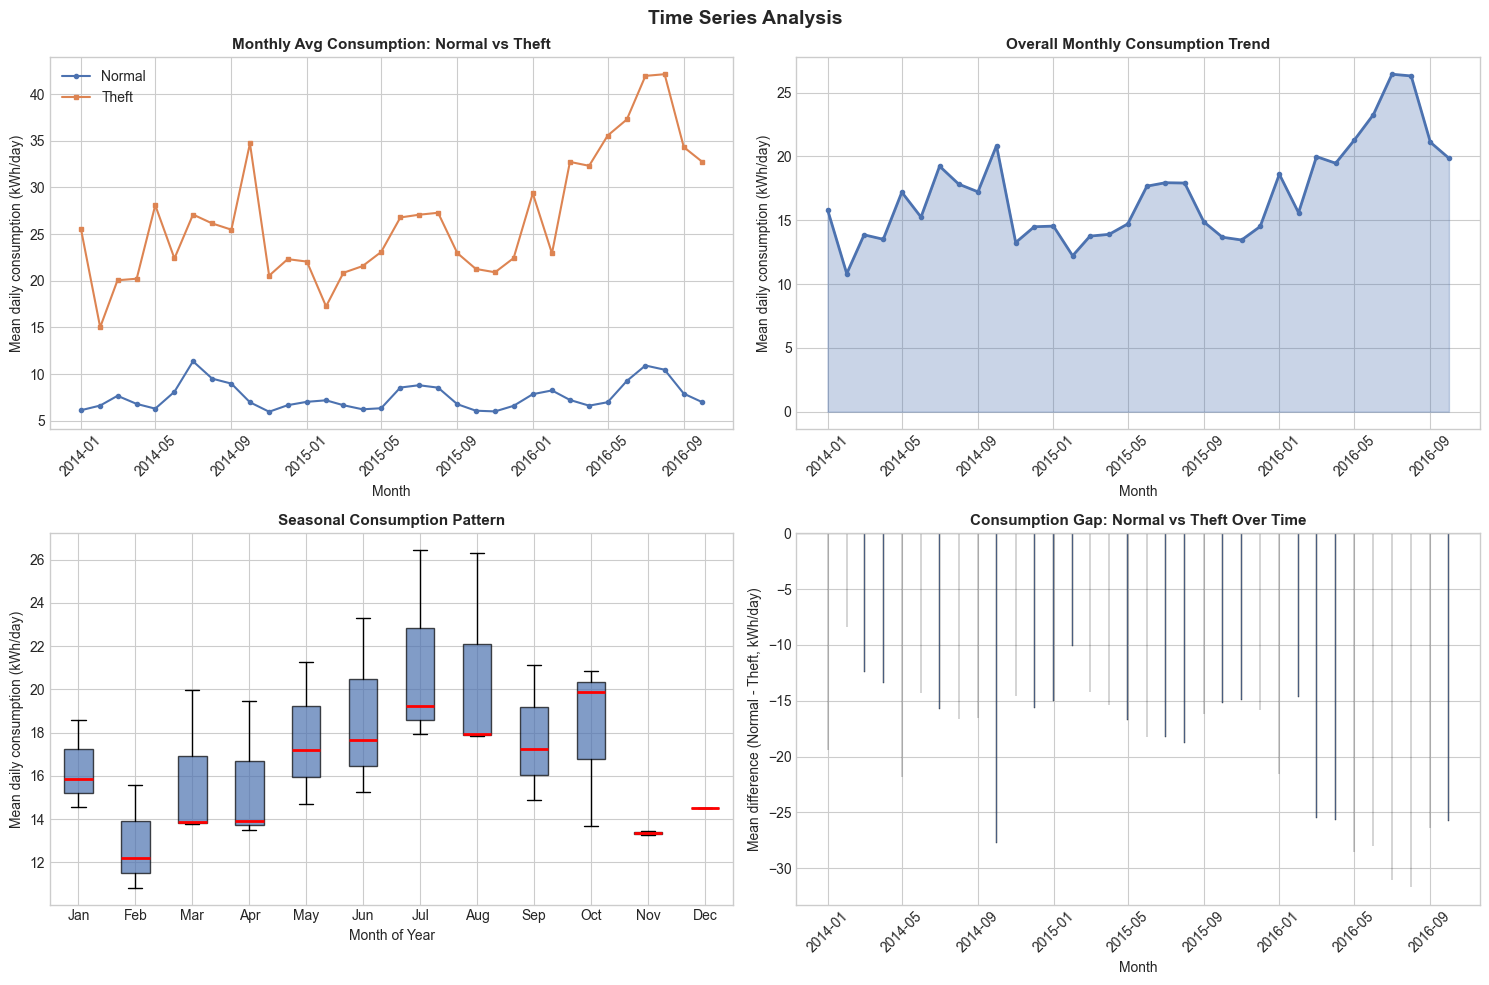


--- Time Series Summary ---
  Date range: 2014-01 -> 2016-10 (34 months)
  Normal avg consumption: 7.597
  Theft avg consumption:  26.548
  Avg gap (Normal - Theft): -18.951
  Max gap month: 2014-02 (-8.393)

Observation: Consumption changes across months and the Normal-Theft gap is not constant, supporting temporal/monthly features. Interpret mean-based trends with outliers in mind.


In [24]:
# Phân tích chuỗi thời gian: tiêu thụ trung bình theo tháng của từng nhóm nhãn
monthly_data = {}
for col in cons_cols:
    dt = pd.to_datetime(col, format='%m/%d/%Y')
    month_key = dt.to_period('M')
    if month_key not in monthly_data:
        monthly_data[month_key] = {'normal': [], 'theft': []}
    monthly_data[month_key]['normal'].append(
        df[df['FLAG'] == 0][col].mean())
    monthly_data[month_key]['theft'].append(
        df[df['FLAG'] == 1][col].mean())

months = sorted(monthly_data.keys())
months_idx = pd.PeriodIndex(months)
normal_monthly = [np.nanmean(monthly_data[m]['normal']) for m in months]
theft_monthly = [np.nanmean(monthly_data[m]['theft']) for m in months]
month_labels = [str(m) for m in months]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Đường xu hướng tiêu thụ trung bình theo tháng: normal vs theft
axes[0, 0].plot(months_idx.to_timestamp(), normal_monthly, color='#4C72B0',
                 linewidth=1.5, label='Normal', marker='o', markersize=3)
axes[0, 0].plot(months_idx.to_timestamp(), theft_monthly, color='#DD8452',
                 linewidth=1.5, label='Theft', marker='s', markersize=3)
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Mean daily consumption (kWh/day)')
axes[0, 0].set_title('Monthly Avg Consumption: Normal vs Theft', fontsize=11, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Xu hướng trung bình theo tháng trên toàn bộ khách hàng
overall_monthly = [(n + t) / 2 for n, t in zip(normal_monthly, theft_monthly)]
axes[0, 1].plot(months_idx.to_timestamp(), overall_monthly, color='#4C72B0',
                 linewidth=2, marker='o', markersize=3)
axes[0, 1].fill_between(months_idx.to_timestamp(), overall_monthly, alpha=0.3, color='#4C72B0')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Mean daily consumption (kWh/day)')
axes[0, 1].set_title('Overall Monthly Consumption Trend', fontsize=11, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Mẫu hình mùa vụ: gom các tháng cùng tên qua nhiều năm
seasonal_data = {m.month: [] for m in months}
for i, m in enumerate(months):
    seasonal_data[m.month].append(overall_monthly[i])

seasonal_df = pd.DataFrame({m: [v] for m, v in seasonal_data.items()}).T
seasonal_df.columns = ['consumption']
seasonal_df = seasonal_df.sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

bp = axes[1, 0].boxplot([seasonal_data[i] for i in range(1, 13) if i in seasonal_data],
                          labels=[month_names[i-1] for i in sorted(seasonal_data.keys())],
                          patch_artist=True,
                          boxprops={'facecolor': '#4C72B0', 'alpha': 0.7},
                          medianprops={'color': 'red', 'linewidth': 2})
axes[1, 0].set_xlabel('Month of Year')
axes[1, 0].set_ylabel('Mean daily consumption (kWh/day)')
axes[1, 0].set_title('Seasonal Consumption Pattern', fontsize=11, fontweight='bold')

# 4. Chênh lệch tiêu thụ giữa normal và theft theo thời gian
diff = [n - t for n, t in zip(normal_monthly, theft_monthly)]
axes[1, 1].bar(months_idx.to_timestamp(), diff, color='#4C72B0', alpha=0.8, edgecolor='black', linewidth=0.3)
axes[1, 1].axhline(0, color='black', linewidth=0.8)
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Mean difference (Normal - Theft, kWh/day)')
axes[1, 1].set_title('Consumption Gap: Normal vs Theft Over Time', fontsize=11, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Time Series Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n--- Time Series Summary ---")
print(f"  Date range: {months[0]} -> {months[-1]} ({len(months)} months)")
print(f"  Normal avg consumption: {np.nanmean(normal_monthly):.3f}")
print(f"  Theft avg consumption:  {np.nanmean(theft_monthly):.3f}")
print(f"  Avg gap (Normal - Theft): {np.nanmean(diff):.3f}")
print(f"  Max gap month: {months[np.argmax(diff)]} ({max(diff):.3f})")
print('\nObservation: Consumption changes across months and the Normal-Theft gap is not constant, supporting temporal/monthly features. Interpret mean-based trends with outliers in mind.')

## 7. Comparative Analysis: Normal vs Theft

Question: Những customer-level statistics nào khác biệt giữa Normal và Theft?

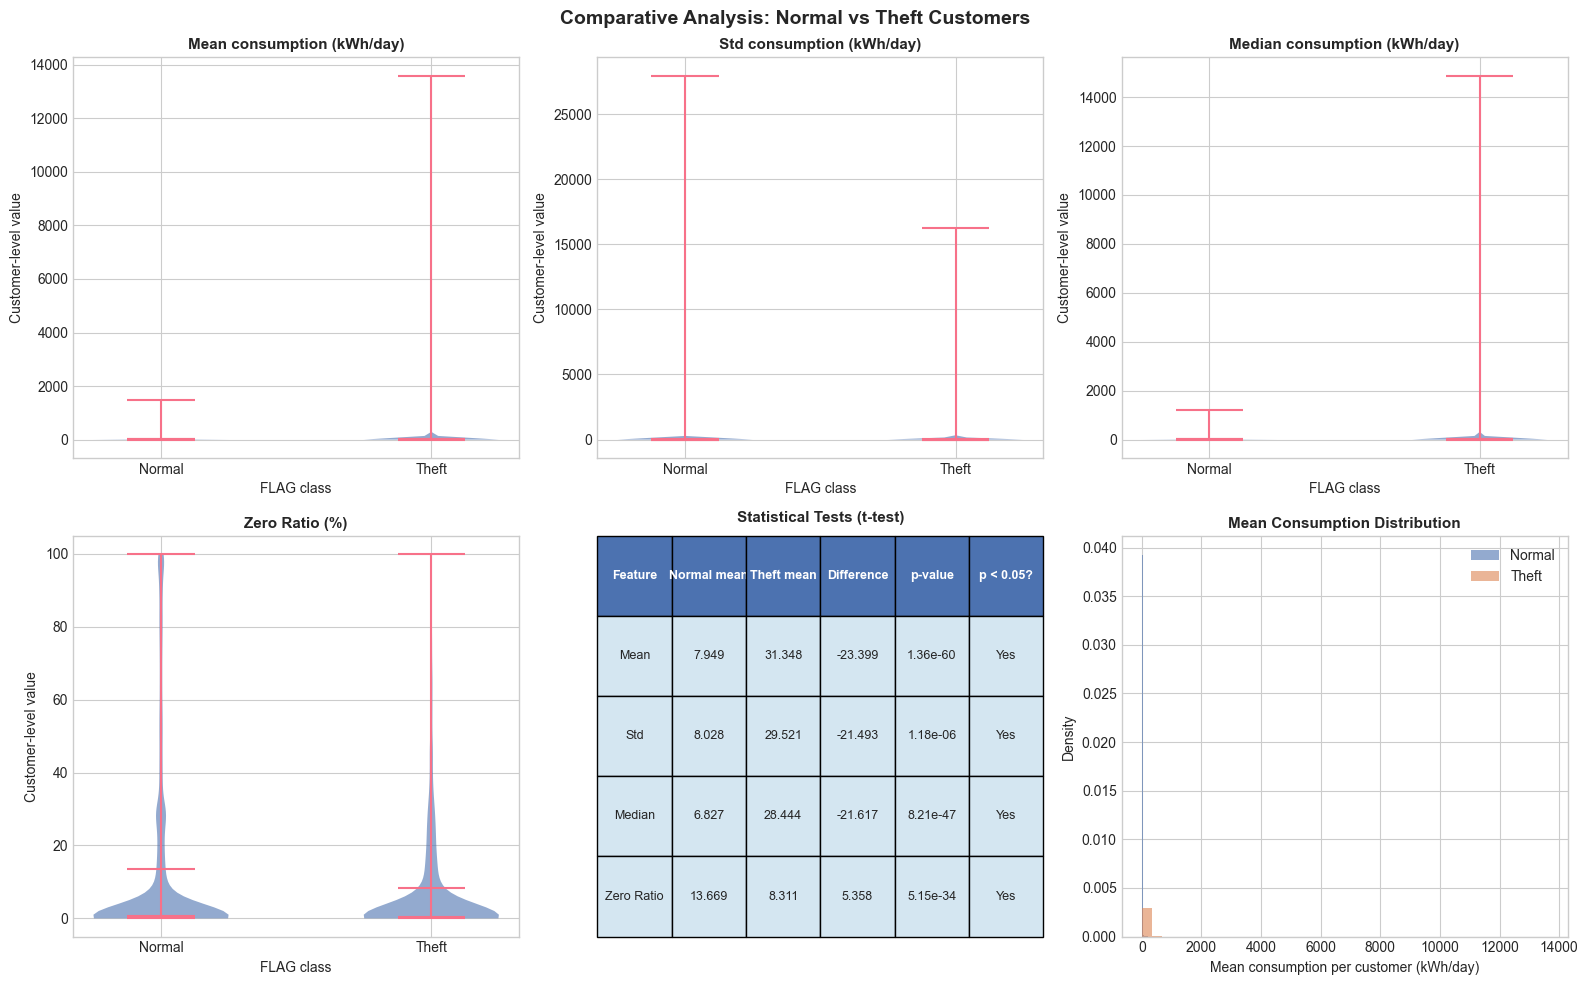


--- Comparative Statistics ---
  Mean: Normal=7.949, Theft=31.348, Diff=-23.399, p=1.36e-60 ***
  Std: Normal=8.028, Theft=29.521, Diff=-21.493, p=1.18e-06 ***
  Median: Normal=6.827, Theft=28.444, Diff=-21.617, p=8.21e-47 ***
  Zero Ratio: Normal=13.669, Theft=8.311, Diff=5.358, p=5.15e-34 ***
  Note: t-test is a quick check; because consumption is skewed, interpret p-values together with the plots.

Observation: Several customer-level statistics differ between Normal and Theft, supporting statistical and behavior-based features in feature.py.


In [25]:
# So sánh normal và theft ở cấp khách hàng
# Tính thống kê cho từng khách hàng trước; cách này khác với việc gom toàn bộ ô tiêu thụ
normal_df = df[df['FLAG'] == 0][cons_cols]
theft_df = df[df['FLAG'] == 1][cons_cols]

normal_mean = normal_df.mean(axis=1)
theft_mean = theft_df.mean(axis=1)
normal_std = normal_df.std(axis=1)
theft_std = theft_df.std(axis=1)
normal_median = normal_df.median(axis=1)
theft_median = theft_df.median(axis=1)
normal_zero = (normal_df == 0).sum(axis=1) / len(cons_cols) * 100
theft_zero = (theft_df == 0).sum(axis=1) / len(cons_cols) * 100

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

stats_data = [
    ('Mean consumption (kWh/day)', normal_mean, theft_mean),
    ('Std consumption (kWh/day)', normal_std, theft_std),
    ('Median consumption (kWh/day)', normal_median, theft_median),
    ('Zero Ratio (%)', normal_zero, theft_zero),
]

for idx, (title, n_data, t_data) in enumerate(stats_data):
    row, col = idx // 3, idx % 3
    vp = axes[row, col].violinplot([n_data.dropna(), t_data.dropna()],
                                    positions=[0, 1], showmeans=True, showmedians=True)
    for pc in vp['bodies']:
        pc.set_facecolor('#4C72B0')
        pc.set_alpha(0.6)
    axes[row, col].set_xticks([0, 1])
    axes[row, col].set_xticklabels(['Normal', 'Theft'])
    axes[row, col].set_xlabel('FLAG class')
    axes[row, col].set_title(title, fontsize=11, fontweight='bold')
    axes[row, col].set_ylabel('Customer-level value')

# Bảng kiểm định t-test để xem khác biệt giữa hai nhóm có ý nghĩa thống kê không
stat_results = []
metrics = [
    ('Mean', normal_mean, theft_mean),
    ('Std', normal_std, theft_std),
    ('Median', normal_median, theft_median),
    ('Zero Ratio', normal_zero, theft_zero),
]
for name, n, t in metrics:
    t_stat, p_val = stats.ttest_ind(n.dropna(), t.dropna())
    stat_results.append({
        'Feature': name,
        'Normal mean': f'{n.mean():.3f}',
        'Theft mean': f'{t.mean():.3f}',
        'Difference': f'{n.mean() - t.mean():.3f}',
        'p-value': f'{p_val:.2e}',
        'p < 0.05?': 'Yes' if p_val < 0.05 else 'No'
    })

stat_df = pd.DataFrame(stat_results)
axes[1, 1].axis('off')
table = axes[1, 1].table(
    cellText=stat_df.values,
    colLabels=stat_df.columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#4C72B0')
        cell.set_text_props(color='white', fontweight='bold')
    elif stat_df.iloc[r-1]['p < 0.05?'] == 'Yes':
        cell.set_facecolor('#D4E6F1')
axes[1, 1].set_title('Statistical Tests (t-test)', fontsize=11, fontweight='bold', pad=10)

# So sánh phân phối mean consumption ở cấp khách hàng
axes[1, 2].hist(normal_mean, bins=60, alpha=0.6, color='#4C72B0', label='Normal', density=True)
axes[1, 2].hist(theft_mean, bins=40, alpha=0.6, color='#DD8452', label='Theft', density=True)
axes[1, 2].set_xlabel('Mean consumption per customer (kWh/day)')
axes[1, 2].set_ylabel('Density')
axes[1, 2].set_title('Mean Consumption Distribution', fontsize=11, fontweight='bold')
axes[1, 2].legend()

plt.suptitle('Comparative Analysis: Normal vs Theft Customers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_comparative_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Comparative Statistics ---")
for name, n, t in metrics:
    t_stat, p_val = stats.ttest_ind(n.dropna(), t.dropna())
    print(f"  {name}: Normal={n.mean():.3f}, Theft={t.mean():.3f}, "
          f"Diff={n.mean()-t.mean():.3f}, p={p_val:.2e} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''}")
print('  Note: t-test is a quick check; because consumption is skewed, interpret p-values together with the plots.')
print('\nObservation: Several customer-level statistics differ between Normal and Theft, supporting statistical and behavior-based features in feature.py.')

## 8. Outlier Detection

Question: Outlier xuất hiện như thế nào và có khác biệt giữa Normal và Theft không?

Note: Phần này dùng IQR trên customer-level statistics cho EDA; preprocessing_v2 dùng thêm ngưỡng raw value > 500 kWh/day để clip.

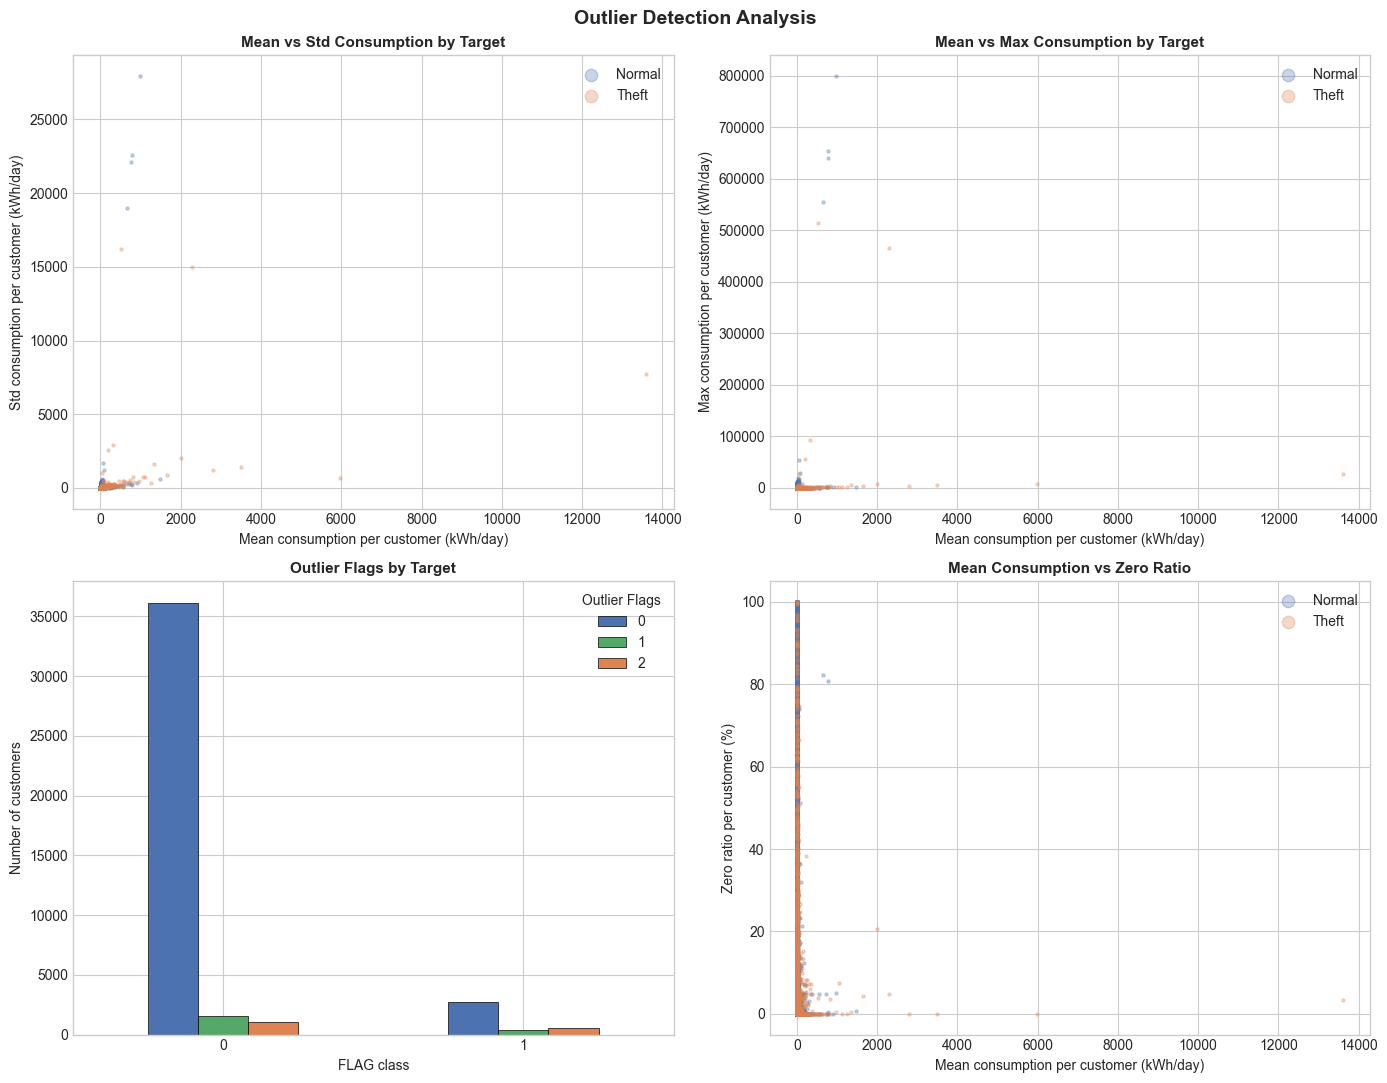


--- Outlier Detection Summary ---
  IQR bounds for mean_cons: [-10.429, 22.664]
  Outliers in mean_cons (Normal): 1,517 / 38,757
  Outliers in mean_cons (Theft):  600 / 3,615
  Avg std (Normal): 8.028
  Avg std (Theft):  29.521
  Avg zero_ratio (Normal): 13.67%
  Avg zero_ratio (Theft):  8.31%


,FLAG,Customers with raw value > 500,Cells > 500
0,Normal (0),485,5880
1,Theft (1),106,15190



Observation: Outlier behavior differs by FLAG. preprocessing_v2 clips extreme values but preserves raw outlier counts in quality_features.csv.


In [26]:
# Phát hiện outlier phục vụ EDA; các cột tạo ở đây chỉ là biến phân tích tạm thời
# Tạo thống kê tổng hợp theo từng khách hàng
df['mean_cons'] = df[cons_cols].mean(axis=1)
df['std_cons'] = df[cons_cols].std(axis=1)
df['max_cons'] = df[cons_cols].max(axis=1)
df['zero_ratio'] = (df[cons_cols] == 0).sum(axis=1) / len(cons_cols) * 100

# Phát hiện outlier bằng IQR trên các thống kê cấp khách hàng
def detect_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return (series < lower) | (series > upper), lower, upper

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 1. Scatter mean vs std, tô màu theo nhãn để nhìn cụm bất thường
colors = df['FLAG'].map({0: '#4C72B0', 1: '#DD8452'})
labels_added = set()
for flag, color, label in [(0, '#4C72B0', 'Normal'), (1, '#DD8452', 'Theft')]:
    mask = df['FLAG'] == flag
    axes[0, 0].scatter(df.loc[mask, 'mean_cons'], df.loc[mask, 'std_cons'],
                       c=color, alpha=0.3, s=5, label=label)
axes[0, 0].set_xlabel('Mean consumption per customer (kWh/day)')
axes[0, 0].set_ylabel('Std consumption per customer (kWh/day)')
axes[0, 0].set_title('Mean vs Std Consumption by Target', fontsize=11, fontweight='bold')
axes[0, 0].legend(markerscale=4)

# 2. Scatter mean vs max để xem khách hàng có đỉnh tiêu thụ bất thường
for flag, color, label in [(0, '#4C72B0', 'Normal'), (1, '#DD8452', 'Theft')]:
    mask = df['FLAG'] == flag
    axes[0, 1].scatter(df.loc[mask, 'mean_cons'], df.loc[mask, 'max_cons'],
                       c=color, alpha=0.3, s=5, label=label)
axes[0, 1].set_xlabel('Mean consumption per customer (kWh/day)')
axes[0, 1].set_ylabel('Max consumption per customer (kWh/day)')
axes[0, 1].set_title('Mean vs Max Consumption by Target', fontsize=11, fontweight='bold')
axes[0, 1].legend(markerscale=4)

# 3. Đếm số cờ outlier IQR theo từng nhóm nhãn
outlier_mask_mean, lo, hi = detect_outliers_iqr(df['mean_cons'])
outlier_mask_std, _, _ = detect_outliers_iqr(df['std_cons'])
df['is_outlier_mean'] = outlier_mask_mean
df['is_outlier_std'] = outlier_mask_std
df['total_outliers'] = df['is_outlier_mean'].astype(int) + df['is_outlier_std'].astype(int)

outlier_counts = df.groupby(['FLAG', 'total_outliers']).size().unstack(fill_value=0)
outlier_counts.plot(kind='bar', ax=axes[1, 0], color=['#4C72B0', '#55A868', '#DD8452', '#C44E52'],
                    edgecolor='black', linewidth=0.5)
axes[1, 0].set_xlabel('FLAG class')
axes[1, 0].set_ylabel('Number of customers')
axes[1, 0].set_title('Outlier Flags by Target', fontsize=11, fontweight='bold')
axes[1, 0].legend(title='Outlier Flags')
axes[1, 0].tick_params(axis='x', rotation=0)

# 4. Quan hệ giữa tỷ lệ ngày bằng 0 và mean consumption
for flag, color, label in [(0, '#4C72B0', 'Normal'), (1, '#DD8452', 'Theft')]:
    mask = df['FLAG'] == flag
    axes[1, 1].scatter(df.loc[mask, 'mean_cons'], df.loc[mask, 'zero_ratio'],
                       c=color, alpha=0.3, s=5, label=label)
axes[1, 1].set_xlabel('Mean consumption per customer (kWh/day)')
axes[1, 1].set_ylabel('Zero ratio per customer (%)')
axes[1, 1].set_title('Mean Consumption vs Zero Ratio', fontsize=11, fontweight='bold')
axes[1, 1].legend(markerscale=4)

plt.suptitle('Outlier Detection Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Outlier Detection Summary ---")
print(f"  IQR bounds for mean_cons: [{lo:.3f}, {hi:.3f}]")
print(f"  Outliers in mean_cons (Normal): {df[df['FLAG']==0]['is_outlier_mean'].sum():,} / {len(df[df['FLAG']==0]):,}")
print(f"  Outliers in mean_cons (Theft):  {df[df['FLAG']==1]['is_outlier_mean'].sum():,} / {len(df[df['FLAG']==1]):,}")
print(f"  Avg std (Normal): {df[df['FLAG']==0]['std_cons'].mean():.3f}")
print(f"  Avg std (Theft):  {df[df['FLAG']==1]['std_cons'].mean():.3f}")
print(f"  Avg zero_ratio (Normal): {df[df['FLAG']==0]['zero_ratio'].mean():.2f}%")
print(f"  Avg zero_ratio (Theft):  {df[df['FLAG']==1]['zero_ratio'].mean():.2f}%")

raw_outlier_mask = df[cons_cols] > 500
raw_outlier_by_flag = pd.DataFrame({
    'FLAG': ['Normal (0)', 'Theft (1)'],
    'Customers with raw value > 500': [
        raw_outlier_mask[df['FLAG'] == 0].any(axis=1).sum(),
        raw_outlier_mask[df['FLAG'] == 1].any(axis=1).sum(),
    ],
    'Cells > 500': [
        raw_outlier_mask[df['FLAG'] == 0].sum().sum(),
        raw_outlier_mask[df['FLAG'] == 1].sum().sum(),
    ],
})
display(raw_outlier_by_flag)
print('\nObservation: Outlier behavior differs by FLAG. preprocessing_v2 clips extreme values but preserves raw outlier counts in quality_features.csv.')

## 9. Summary & Insights

Mục tiêu: tóm tắt ngắn các insight ảnh hưởng trực tiếp tới preprocessing và feature engineering.

In [27]:
# Tổng hợp insight chính từ EDA
print("=" * 65)
print("       EDA SUMMARY: ENERGY THEFT DETECTION DATASET")
print("=" * 65)

print("""
KEY EDA FINDINGS:
1. Class imbalance: Normal is the majority class, Theft is the minority class.
   Impact: Accuracy alone is not enough; use Recall, F1-score, PR-AUC, and class balancing.

2. Consumption distribution: daily consumption is skewed and contains extreme values.
   Impact: mean-based features are useful but should be combined with median, IQR, log, and outlier-aware features.

3. Missing values: missing rate is high and differs between Normal and Theft.
   Impact: missing count/ratio should be kept as features, not only filled away during preprocessing.

4. Zero consumption: zero-ratio differs between target groups.
   Impact: zero-count and zero-ratio are relevant behavior features.

5. Time behavior: monthly consumption and the Normal-Theft gap change over time.
   Impact: temporal features such as monthly statistics, trend, and volatility are justified.

6. Outliers: outlier behavior differs by FLAG.
   Impact: preprocessing_v2 should clip extreme raw values while preserving outlier indicators in quality_features.csv.

FEATURE ENGINEERING DIRECTION:
1. Statistical features: mean, std, median, min, max, range, quantiles.
2. Data quality features: missing count/ratio, zero count/ratio, raw outlier count.
3. Temporal features: monthly mean/std, trend, change rate, recent-vs-old consumption.
4. Stability features: coefficient of variation, rolling std, max/mean, std/mean.
""")

# Tạo bảng tóm tắt số liệu chính để đưa vào báo cáo
summary_stats = pd.DataFrame({
    'Metric': ['Total customers', 'Tracking period (days)', 'Missing cells (%)',
               'Normal customers (%)', 'Theft customers (%)', 'Normal mean daily consumption',
               'Theft mean daily consumption', 'Normal zero ratio', 'Theft zero ratio'],
    'Value': [
        f'{len(df):,}',
        f'{len(cons_cols):,}',
        f'{missing_pct:.2f}%',
        f'{target_pct[0]:.2f}%',
        f'{target_pct[1]:.2f}%',
        f'{normal_cons.mean():.3f}',
        f'{theft_cons.mean():.3f}',
        f'{(normal_cons==0).mean()*100:.2f}%',
        f'{(theft_cons==0).mean()*100:.2f}%',
    ]
})
print("\nSUMMARY TABLE:")
print(summary_stats.to_string(index=False))

       EDA SUMMARY: ENERGY THEFT DETECTION DATASET

KEY EDA FINDINGS:
1. Class imbalance: Normal is the majority class, Theft is the minority class.
   Impact: Accuracy alone is not enough; use Recall, F1-score, PR-AUC, and class balancing.

2. Consumption distribution: daily consumption is skewed and contains extreme values.
   Impact: mean-based features are useful but should be combined with median, IQR, log, and outlier-aware features.

3. Missing values: missing rate is high and differs between Normal and Theft.
   Impact: missing count/ratio should be kept as features, not only filled away during preprocessing.

4. Zero consumption: zero-ratio differs between target groups.
   Impact: zero-count and zero-ratio are relevant behavior features.

5. Time behavior: monthly consumption and the Normal-Theft gap change over time.
   Impact: temporal features such as monthly statistics, trend, and volatility are justified.

6. Outliers: outlier behavior differs by FLAG.
   Impact: preproc